# Loading

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [80]:
BASEDIR = "../LOGS"

runs = pd.read_csv(os.path.join(BASEDIR, "runs.csv"))
search_info = pd.read_csv(os.path.join(BASEDIR, "search_settings.csv"))
dataset_info = pd.read_csv(os.path.join(BASEDIR, "dataset_settings.csv"))
index_info = pd.read_csv(os.path.join(BASEDIR, "index_settings.csv"))

# Join the three settings dataframes on dataset_file
info = search_info.join(dataset_info.set_index('dataset_file'), on='dataset_file', how='left', rsuffix='_dataset')
info = info.join(index_info.set_index('index_file'), on='index_file', how='left', rsuffix='_index')

# Join the two dataframes where runs['settings_id'] is the id of the search settings
df = pd.merge(runs, info, left_on='settings_id', right_on='id', how='left', suffixes=('_run', '_settings'))

print(df.columns)

df

Index(['id_run', 'settings_id', 'query_id', 'query_length', 'query_channels',
       'result_set_ts_indices', 'result_set_ts_positions',
       'result_set_distances', 'num_leaves_visited', 'num_nodes_visited',
       'num_ts_examined', 'total_time_s', 'first_layer_time_s',
       'tree_traversal_time_s', 'io_time_s', 'ts_examination_time_s',
       'id_settings', 'index_file', 'dataset_file', 'ffts_file', 'query_file',
       'num_queries', 'query_type', 'r_range_r', 'knn_k', 'exact',
       'normalized', 'search_method', 'distance_measure', 'early_abandoning',
       'id_dataset', 'series_length', 'num_channels', 'num_series', 'sd',
       'source_csvs', 'low_sd_len', 'id_index', 'dataset_file_index',
       'ffts_file_index', 'l_min', 'l_max', 'normalized_index', 'index_type',
       'segment_length', 'pos_per_env', 'first_layer_num_bits',
       'leaf_capacity', 'breakpoint_strategy', 'split_strategy',
       'min_num_bits_on_tie', 'num_bits_limit', 'indexing_time_s',
       'fft_c

,id_run,settings_id,query_id,query_length,query_channels,result_set_ts_indices,result_set_ts_positions,result_set_distances,num_leaves_visited,num_nodes_visited,...,segment_length,pos_per_env,first_layer_num_bits,leaf_capacity,breakpoint_strategy,split_strategy,min_num_bits_on_tie,num_bits_limit,indexing_time_s,fft_calc_time_s
0,0,0,0,512,1;0;1;1,1,322,0.318006,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,1,512,1;1;1;1,31,299,0.301724,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0,2,1024,1;0;1;1,110,0,0.154127,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0,3,730,1;1;1;1,171,154,0.316969,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0,4,1024,1;0;0;1,172,0,0.257429,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4134,3776,39,57,1024,1;1;1;1;1,964,310,3.082349,295,303,...,32.0,1034.0,1.0,64.0,equiprobable,entropy_maximizing,1.0,12.0,65.138045,1.333984
4135,3777,39,58,1024,1;1;1;1;1,989,195,483.346404,374,382,...,32.0,1034.0,1.0,64.0,equiprobable,entropy_maximizing,1.0,12.0,65.138045,1.333984
4136,3777,39,58,1024,1;1;1;1;1,989,195,483.346404,374,382,...,32.0,1034.0,1.0,64.0,equiprobable,entropy_maximizing,1.0,12.0,65.138045,1.333984
4137,3778,39,59,1024,1;1;1;1;1,990,856,0.803406,290,298,...,32.0,1034.0,1.0,64.0,equiprobable,entropy_maximizing,1.0,12.0,65.138045,1.333984


In [81]:
# Infer necessary columns
ALGOS = ['BRUTE_FORCE', 'MASS', 'MULISSE', 'MULISSE_ED']

# Algorithm -- dependent on combinations of search method and distance measure
def get_algorithm(row):
    search_method = row.search_method
    distance_measure = row.distance_measure
    ffts_precomputed = not pd.isna(row.ffts_file)
    # early_abandon = row.early_abandoning
    early_abandon = True

    if 'scan' in search_method and distance_measure == 'ed' and not ffts_precomputed and early_abandon:
        return 'BRUTE_FORCE'
    elif 'scan' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MASS'
    elif 'isax' in search_method and distance_measure == 'ed' and early_abandon:
        return 'MULISSE_ED'
    elif 'isax' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MULISSE'
    else:
        return np.nan
    
df['algorithm'] = df.apply(get_algorithm, axis=1)

df['dataset'] = df.dataset_file.str.extract(r'(\w+).bin')

df['num_query_channels'] = df.query_channels.str.count('1')

df[['algorithm', 'dataset', 'query_channels', 'num_query_channels', 'num_series', 'series_length', 'num_channels']]

,algorithm,dataset,query_channels,num_query_channels,num_series,series_length,num_channels
0,BRUTE_FORCE,rwalk_N5000_C4_M1024,1;0;1;1,3,5000,1024,4
1,BRUTE_FORCE,rwalk_N5000_C4_M1024,1;1;1;1,4,5000,1024,4
2,BRUTE_FORCE,rwalk_N5000_C4_M1024,1;0;1;1,3,5000,1024,4
3,BRUTE_FORCE,rwalk_N5000_C4_M1024,1;1;1;1,4,5000,1024,4
4,BRUTE_FORCE,rwalk_N5000_C4_M1024,1;0;0;1,2,5000,1024,4
...,...,...,...,...,...,...,...
4134,MULISSE,stocks_n1000_m2048_c5,1;1;1;1;1,5,1000,2048,35952
4135,MULISSE,stocks_n1000_m2048_c5,1;1;1;1;1,5,1000,2048,5
4136,MULISSE,stocks_n1000_m2048_c5,1;1;1;1;1,5,1000,2048,35952
4137,MULISSE,stocks_n1000_m2048_c5,1;1;1;1;1,5,1000,2048,5


# Test

In [86]:
# view = df[
#     (df.algorithm.isna() == False) &
#     (df.dataset.str.startswith("weather")) &
#     (df.num_channels == 4) &
#     (df.num_query_channels == 4) &
#     (df.num_series == 1000) &
#     (df.series_length == 1024) &
#     # ((~df.algorithm.str.contains("MULISSE")) | (df.query_length >= df.l_min)) &
#     True
# ]

view = df[
    (df.algorithm.isna() == False) &
    (df.dataset.str.startswith("stocks")) &
    (df.num_channels == 5) &
    (df.num_query_channels == 5) &
    (df.num_series == 1000) &
    (df.series_length == 2048) &
    (df.query_length.isin([1024, 1536, 2048])) &
    ((~df.algorithm.str.contains("MULISSE")) | (df.l_min == 1024)) &
    True
]

# view = df[
#     (df.algorithm.isna() == False) &
#     (df.dataset.str.startswith("rwalk")) &
#     (df.num_channels == 4) &
#     (df.num_query_channels == 4) &
#     (df.num_series == 5000) &
#     (df.series_length == 2048) &
#     # ((~df.algorithm.str.contains("MULISSE")) | (df.query_length >= df.l_min)) &
#     True
# ]

view.groupby(['algorithm', 'query_length']).size().unstack()

query_length,1024,1536,2048
algorithm,,,
MASS,20,40,40
MULISSE,20,20,20


In [87]:
view.groupby(['algorithm', 'query_length']).total_time_s.median().unstack()

query_length,1024,1536,2048
algorithm,,,
MASS,0.636124,0.784674,0.764112
MULISSE,0.666375,0.589511,0.180160


<AxesSubplot:xlabel='query_length'>

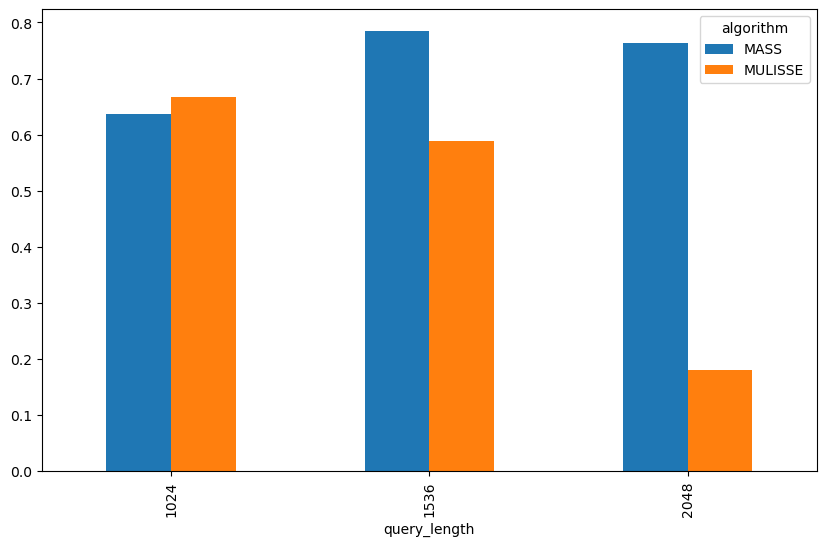

In [88]:
fig, ax = plt.subplots(figsize=(10, 6))

view.groupby(['query_length', "algorithm"]).total_time_s.median().unstack().plot(kind='bar', ax=ax)

# ax.set_yscale("log")

In [89]:
view.groupby(['algorithm', 'query_length']).num_ts_examined.median().unstack()

query_length,1024,1536,2048
algorithm,,,
MASS,1000.0,1000.0,1000.0
MULISSE,922.5,872.0,241.5
